<a href="https://colab.research.google.com/github/PedroIvoLeite/Colab/blob/main/Final_CD_PPGTI_Exercicio_Tratamento_de_Dados_alugueis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><b>Ciência de Dados</b><h1>
<h2>Disciplina: Ciência de Dados</h2>
<h3>Mestrado Profissional em Tecnologia da Informação</h3>
<h3>Aluno: Pedro Ivo Santos Leite</h3>
<b>Professores(as):</b>
<br>
Damires Yluska<br>
Alex Sandro



In [1]:
# consultando a versão do Python instalado na VM do Colab
!python -V

Python 3.12.13


<H1><b>📘 Introdução</b></h1>

Neste exercício, você irá explorar um dataset contendo informações sobre vários imóveis alugados no Rio de Janeiro. Há uma grande variedade de tipos de imóveis.

Entretanto, o dataset necessita de um tratamento (pré-processamento) para que seja possível realizar análises e, futuramente, submetê-lo a tarefas de aprendizado supervisionado (e.g. Regressão) ou não-supervisionado (e.g. agrupamento).

Com base na teoria vista em sala de aula, **explore o dataset realize os tratamentos necessários neste notebook**. Para facilitar o entendimento do trabalho realizado, crie seções que norteiem as etapas de tratamento que você realizou. Não utilize só célula de código: com o apoio de células de texto, registre o racional para as decisões tomadas, de forma organizada.

# 1.Carga dos Dados

##1.1 A partir de um link no `GitHub`

In [2]:
# consultando a versão do Python instalado na VM do Colab
!python -V

Python 3.12.13


In [3]:
import pandas as pd
import numpy as np
from datetime import datetime

# Caminho completo para o arquivo
url = 'https://raw.githubusercontent.com/alex-ifpb/datasets/refs/heads/main/ciencia_de_dados/aluguel.csv'

# Carregando o dataset
df_aluguel = pd.read_csv(url,sep=';')

# Exibindo as primeiras linhas
df_aluguel.head(5)


,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


In [4]:
#Criar backup do CSV

# Gera um nome com data e hora: backup_2024-05-20_14-30.csv
data_aluguel = datetime.now().strftime('%Y-%m-%d_%H-%M')
nome_backup = f'backup_{data_aluguel}.csv'

# Salva o backup
df_aluguel.to_csv(nome_backup, index=False)
print(f"Backup criado: {nome_backup}")

Backup criado: backup_2026-05-14_22-16.csv


#2.Explorando o dataset

O primeiro contato que é feito com o dataset tem o objetivo de obter um panorama geral dados em relação a:
1. Conhecer seus metadados
2. Explorar o domínio de valores de seus atributos
3. Identificar a existências de valores nulos, entradas de dados incorretas e formato dos dados
4. Levantar estatísticas sobre os dados.

🚨 **Importante**

Neste exercício, realize o tratamento apenas para imóveis **residenciais**.

Apresenta o DataFrame e suas estatísticas descritivas para cada coluna: media, valor padrão, maximo, minmo e seus quartis. As colunas Tipo e Bairro serão os valores categóricos,

In [5]:
df_aluguel.describe()

,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
count,32960.000000,32960.000000,32960.000000,32960.000000,3.294300e+04,2.886700e+04,2.272300e+04
mean,1.771390,1.749059,0.665777,231.901547,1.295266e+04,2.388062e+03,2.364410e+03
std,1.717869,20.380402,1.176525,1135.254152,6.675220e+05,3.918496e+04,1.795641e+05
min,0.000000,0.000000,0.000000,0.000000,7.500000e+01,1.000000e+00,1.000000e+00
25%,0.000000,0.000000,0.000000,55.000000,1.500000e+03,5.900000e+02,1.100000e+02
50%,2.000000,1.000000,0.000000,87.000000,2.800000e+03,9.900000e+02,2.500000e+02
75%,3.000000,2.000000,1.000000,170.000000,6.500000e+03,1.800000e+03,6.970000e+02
max,100.000000,1966.000000,70.000000,90000.000000,1.200000e+08,6.552570e+06,2.705307e+07


In [6]:
df_aluguel.info()
# Sumário do DatFrame, 32.960 instâcias  com 9 colunas cada, objetos (2), int64(4), float(64) tipos de dados.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  object 
 1   Bairro      32960 non-null  object 
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.3+ MB


In [7]:
df_aluguel.nunique()
# Quantidade de valores únicos para cada coluna.

,0
Tipo,22
Bairro,162
Quartos,20
Vagas,71
Suites,15
Area,1171
Valor,1414
Condominio,3811
IPTU,2765


In [8]:
#Contagem de valores para uma coluna específica: 19.532 apartamentos
df_aluguel['Tipo'].value_counts()

,count
Tipo,
Apartamento,19532
Conjunto Comercial/Sala,6815
Loja/Salão,1426
Casa de Condomínio,996
Casa,967
Quitinete,836
Galpão/Depósito/Armazém,623
Flat,476
Prédio Inteiro,301


#3.Tratando os dados

É hora de tomar as decisões! De forma organizada, aponte os tratamentos que serão realizados.

A limpeza busca assegurar a qualidade, integridade e consistência dos dados. Normalmente, são realizadas tarefas de:
* imputação de valores ausentes; **`OK`**
* remoção de ruídos; **`OK`**
* identificação de valores imprecisos ou incorretos;
* análise e tratamento de outliers; **`OK`**
* interpolação de dados (temporais);
* discretização de atributos;
* adequação de valores à mesma escala;
* capitalização e formatação em geral (e.g. sexo="masculino" para sexo='M')
* eliminação de atributos e/ou linhas;
* Identificação e Tratamento de outliers;


### 3.1 Verifica a existencia de dados duplicados

In [9]:
duplicated_count = df_aluguel.duplicated().sum()
print("Quantidade de dados duplicados:", duplicated_count)

Quantidade de dados duplicados: 1160


In [10]:
# Elimina os registros duplicados duplicadas

df_aluguel.drop_duplicates(inplace=True)
print('DataFrame após a remoção de duplicados:', df_aluguel.shape)

DataFrame após a remoção de duplicados: (31800, 9)


In [11]:
# Verificar valores faltantes
print('Valores faltantes por coluna:')
df_aluguel.isnull().sum()

Valores faltantes por coluna:


,0
Tipo,0
Bairro,0
Quartos,0
Vagas,0
Suites,0
Area,0
Valor,17
Condominio,3949
IPTU,9886


### 3.2 Tratamento de Valores Ausentes

Vamos preencher os valores ausentes nas colunas `Valor`, `Condominio` e `IPTU` utilizando a mediana. A mediana é uma medida de tendência central robusta a *outliers*, sendo uma boa escolha quando há suspeita de valores extremos nos dados que poderiam distorcer a média. Isso ajudará a manter a distribuição dos dados de forma mais representativa.

In [12]:
import pandas as pd

# Calculando a mediana para as colunas com valores ausentes
median_valor = df_aluguel['Valor'].median()
median_condominio = df_aluguel['Condominio'].median()
median_iptu = df_aluguel['IPTU'].median()

print(f"Mediana de Valor: {median_valor}")
print(f"Mediana de Condominio: {median_condominio}")
print(f"Mediana de IPTU: {median_iptu}")

# Preenchendo os valores ausentes com a mediana (evitando o FutureWarning)
df_aluguel['Valor'] = df_aluguel['Valor'].fillna(median_valor)
df_aluguel['Condominio'] = df_aluguel['Condominio'].fillna(median_condominio)
df_aluguel['IPTU'] = df_aluguel['IPTU'].fillna(median_iptu)

# Verificando novamente os valores faltantes para confirmar o preenchimento
print('\nValores faltantes após o preenchimento:')
df_aluguel.isnull().sum()

Mediana de Valor: 2800.0
Mediana de Condominio: 980.0
Mediana de IPTU: 250.0

Valores faltantes após o preenchimento:


,0
Tipo,0
Bairro,0
Quartos,0
Vagas,0
Suites,0
Area,0
Valor,0
Condominio,0
IPTU,0


In [13]:
# Verificacao se realmente os dados estao preenchidos.
df_aluguel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31800 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        31800 non-null  object 
 1   Bairro      31800 non-null  object 
 2   Quartos     31800 non-null  int64  
 3   Vagas       31800 non-null  int64  
 4   Suites      31800 non-null  int64  
 5   Area        31800 non-null  int64  
 6   Valor       31800 non-null  float64
 7   Condominio  31800 non-null  float64
 8   IPTU        31800 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.4+ MB


### Distribuição do Tipo de Imóvel (Gráfico de Barras)

Vamos visualizar a proporção de cada tipo de imóvel residencial no dataset após os tratamentos. Um gráfico de barras é ideal para mostrar a frequência ou contagem de cada categoria, permitindo uma comparação visual rápida da prevalência de cada tipo de aluguel.

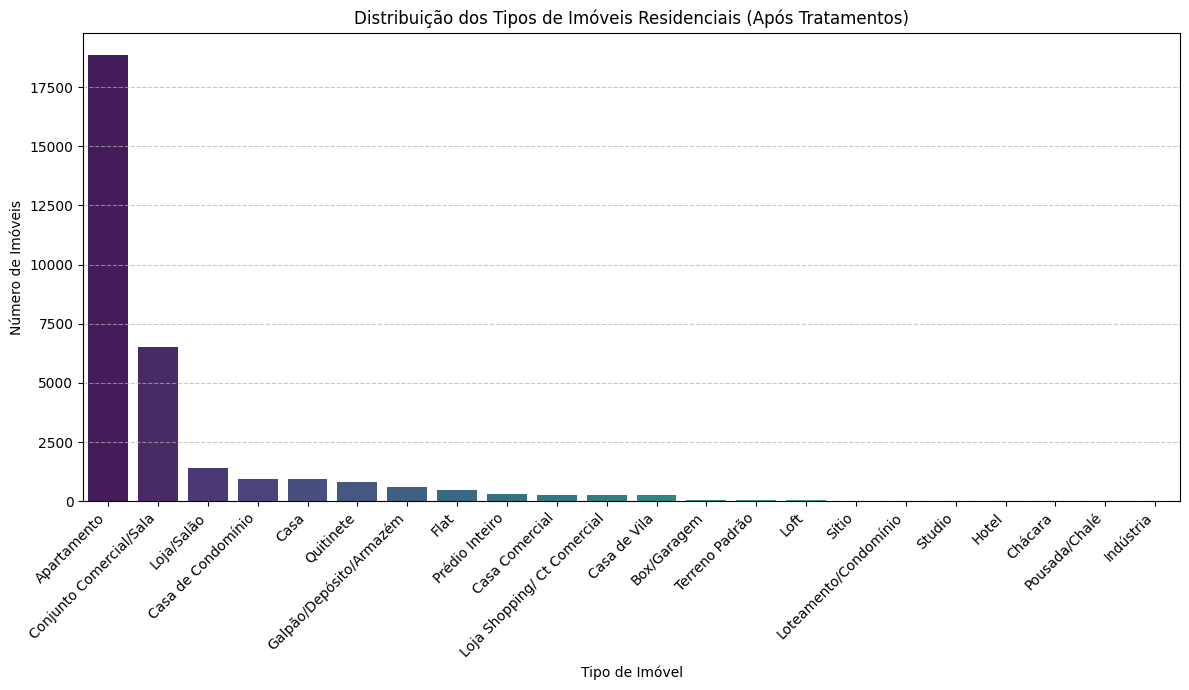

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar a ocorrência de cada tipo de imóvel
distribuicao_tipo_res = df_aluguel['Tipo'].value_counts()

# Criar o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x=distribuicao_tipo_res.index, y=distribuicao_tipo_res.values, hue=distribuicao_tipo_res.index, palette='viridis', legend=False)
plt.title('Distribuição dos Tipos de Imóveis Residenciais (Após Tratamentos)')
plt.xlabel('Tipo de Imóvel')
plt.ylabel('Número de Imóveis')
plt.xticks(rotation=45, ha='right') # Rotacionar os rótulos do eixo x para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajustar o layout para evitar sobreposição
plt.show()

### Distribuição por Tipo de Imovel por Bairro (Gráfico de Pizza)

Vamos visualizar a proporção de cada tipo de imóvel no dataset utilizando um gráfico de pizza. Isso nos ajuda a entender rapidamente quais tipos de imóveis são mais ou menos frequentes.

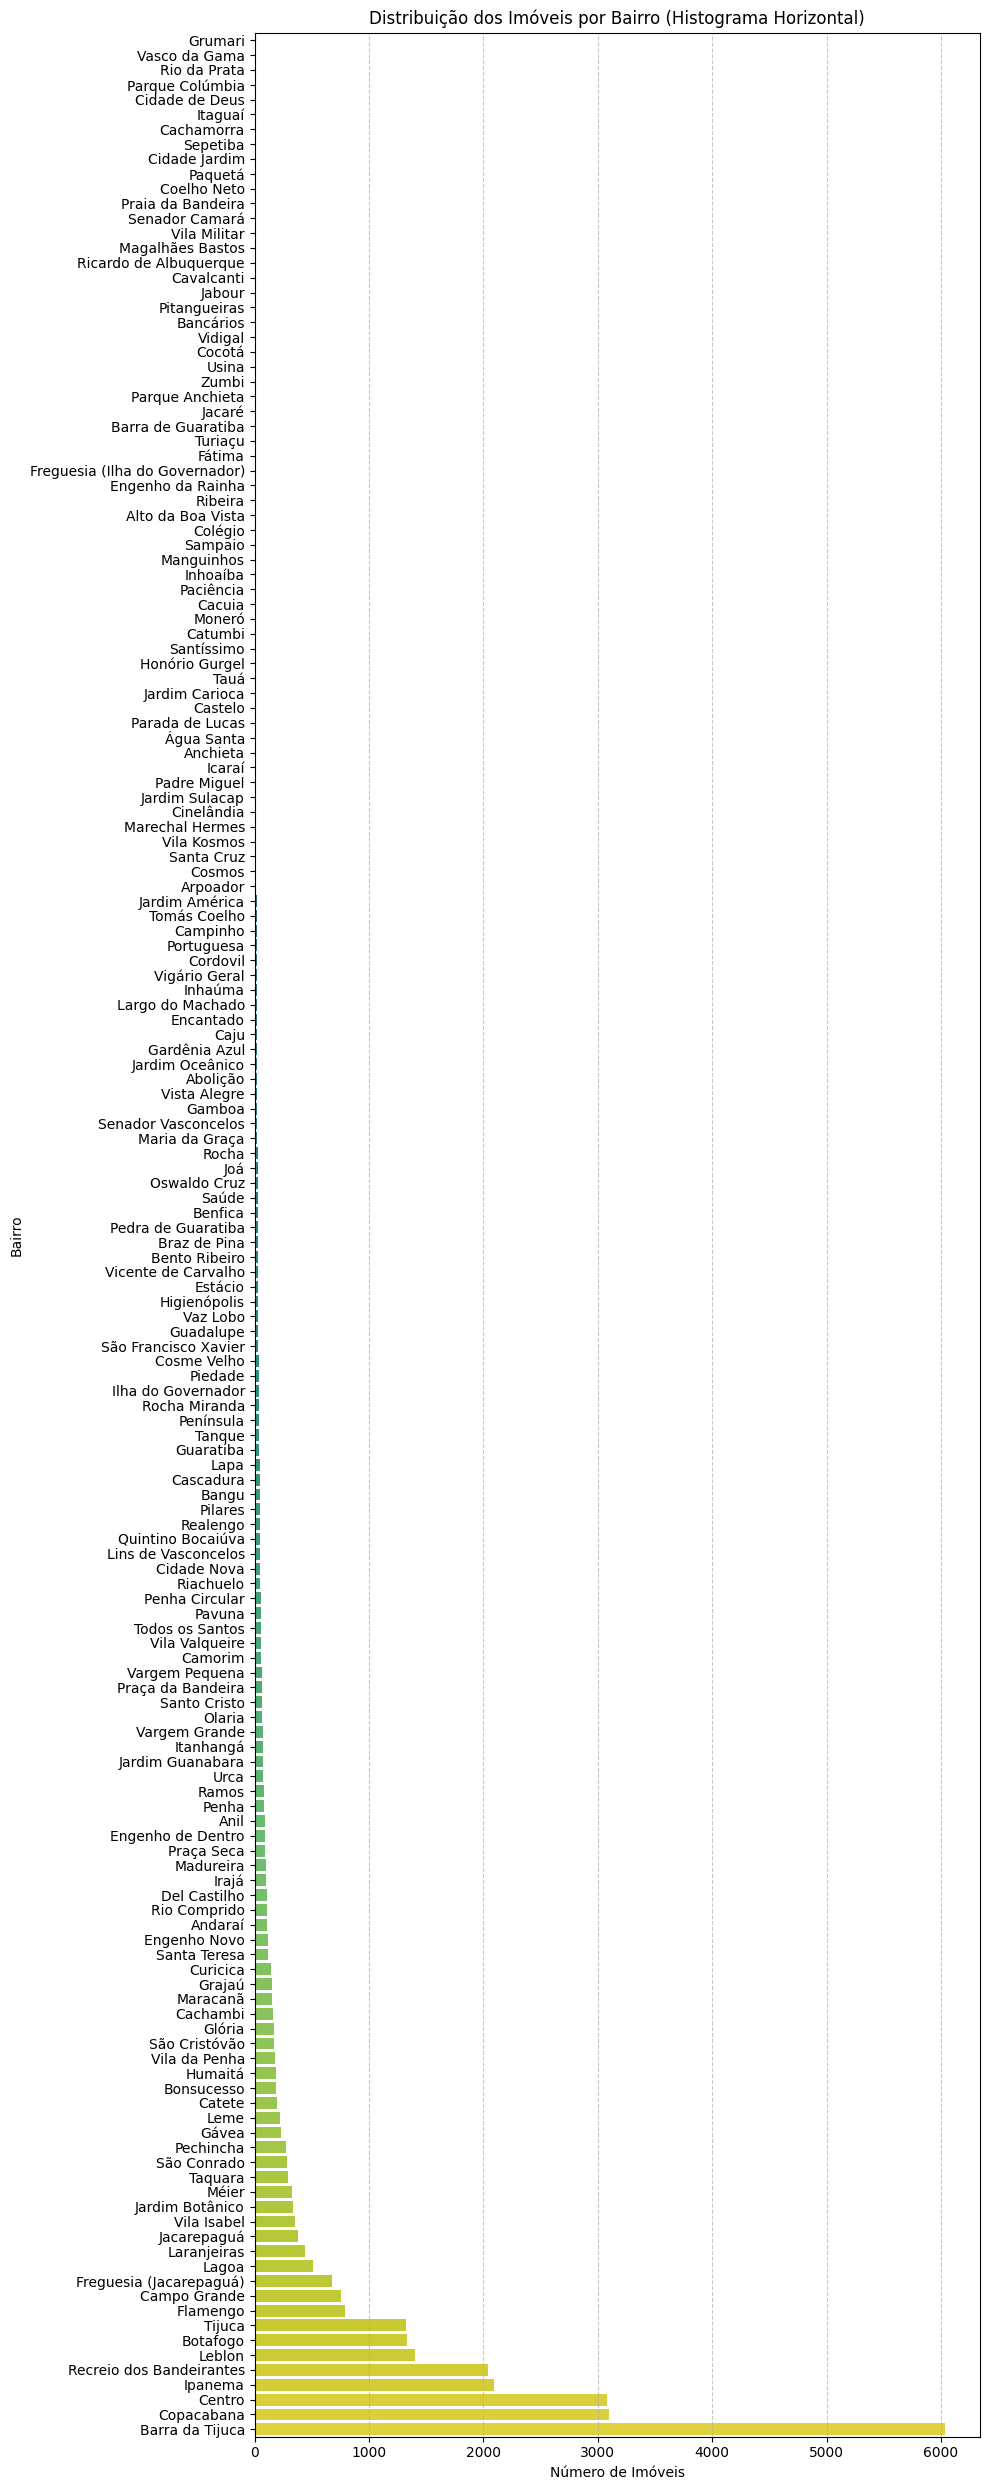

In [15]:
# Contar a ocorrência de imoveis por bairro e ordenar para melhor visualização
distribuicao_tipo = df_aluguel['Bairro'].value_counts().sort_values(ascending=True)

# Criar o gráfico de barras horizontal (histograma horizontal)
plt.figure(figsize=(10, 25)) # Aumentar a altura para dar mais espaço aos rótulos
sns.barplot(x=distribuicao_tipo.values, y=distribuicao_tipo.index, hue=distribuicao_tipo.index, palette='viridis', legend=False)
plt.title('Distribuição dos Imóveis por Bairro (Histograma Horizontal)')
plt.xlabel('Número de Imóveis')
plt.ylabel('Bairro')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajustar o layout para evitar sobreposição
plt.show()

É hora de tomar as decisões! De forma organizada, aponte os tratamentos que serão realizados.

A limpeza busca assegurar a qualidade, integridade e consistência dos dados. Normalmente, são realizadas tarefas de:
* imputação de valores ausentes; **`OK`**
* remoção de ruídos; **`OK`**
* identificação de valores imprecisos ou incorretos;**`OK`**
* análise e tratamento de outliers; **`OK`**
* interpolação de dados (temporais);
* discretização de atributos;
* adequação de valores à mesma escala;
* capitalização e formatação em geral (e.g. sexo="masculino" para sexo='M')
* eliminação de atributos e/ou linhas;
* Identificação e Tratamento de outliers;


#4.Pré-Processamento

### 4.1 Selecionar somente os imoveis residenciais

In [16]:
tipos_residenciais = ['Apartamento', 'Casa', 'Casa de Condomínio', 'Casa de Vila', 'Quitinete', 'Flat', 'Loft', 'Studio', 'Sítio', 'Chácara', 'Pousada/Chalé']
df_aluguel = df_aluguel[df_aluguel['Tipo'].isin(tipos_residenciais)]

print(f"DataFrame após a seleção de imóveis residenciais: {df_aluguel.shape}")
print("Contagem de tipos de imóveis após o filtro:")
print(df_aluguel['Tipo'].value_counts())

DataFrame após a seleção de imóveis residenciais: (22351, 9)
Contagem de tipos de imóveis após o filtro:
Tipo
Apartamento           18854
Casa de Condomínio      963
Casa                    937
Quitinete               827
Flat                    459
Casa de Vila            245
Loft                     51
Sítio                     9
Studio                    4
Chácara                   1
Pousada/Chalé             1
Name: count, dtype: int64


# Variaveis de Interesse e variáveis Categóricas

In [17]:
variaveis_de_interesse = ['Quartos', 'Vagas', 'Suites','Area','Valor']
variaveis_categoricas = ['Bairro', 'Tipo']

### 4.2 Distribuição conjunta de todas as variáveis de interesse

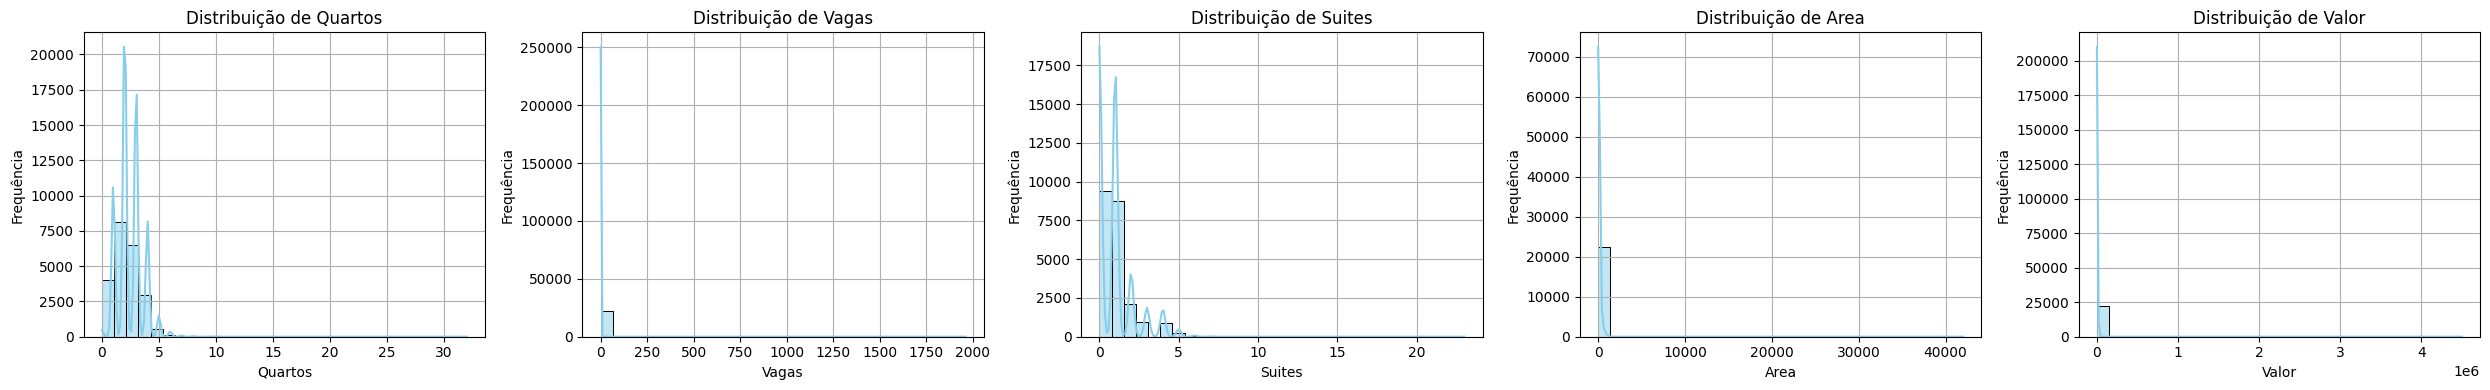

In [18]:
#===================================================================================
#   Distribuição conjunta de todas as variáveis. É importantes notar que todas elas
#   apresentam uma distrinuição normal. Se a intenção for usar testes não
#   paramétricos podemos utilizar alternativas não paramétricos: Mann-Whitney U,
#   Kruskal-Wallis e outros, ou tentar fazer transformações do tipo o Z-score
#===================================================================================

import math
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Número de colunas por linha
colunas_por_linha = 5

# Número total de variáveis
total = len(variaveis_de_interesse)

# Número de linhas necessárias (arredondado para cima
linhas = math.ceil(total / colunas_por_linha)

# Tamanho da figura ajustado à quantidade de linhas/colunas
fig, axes = plt.subplots(linhas, colunas_por_linha, figsize=(5 * colunas_por_linha, 4 * linhas))
axes = axes.flatten()  # transforma para vetor 1D para facilitar iteração

# Gera um histograma com KDE para cada variável
for i, coluna in enumerate(variaveis_de_interesse):
    ax = axes[i]
    sns.histplot(data=df_aluguel, x=coluna, kde=True, bins=30, ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribuição de {coluna}', fontsize=12)
    ax.set_xlabel(coluna)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Remove eixos vazios se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 4.3 Remoção de Ruídos em Colunas Numéricas

Após filtrar pelos tipos de imóveis residenciais, é crucial lidar com valores que podem ser considerados ruído ou erros de entrada de dados. Identificamos algumas colunas numéricas com valores máximos que parecem irrealistas para imóveis residenciais. Vamos aplicar limites razoáveis para as colunas `Quartos`, `Vagas`, `Suites`, `Area`, `Valor`, `Condominio` e `IPTU` para remover esses ruídos.

*   **`Quartos`**: Máximo de 8. Embora existam casas com mais quartos, para uma análise geral, valores acima de 8 são considerados extremos.
*   **`Vagas`**: Máximo de 5. É raro um imóvel residencial ter mais de 5 vagas de garagem.
*   **`Suites`**: Máximo de 5. Similar às vagas, um número muito elevado de suítes é incomum para residências típicas.
*   **`Area`**: Máximo de 1000 m². Valores acima disso são geralmente para imóveis muito grandes ou propriedades comerciais, que já deveriam ter sido removidas pelo filtro de tipo, mas ainda podem conter ruído.
*   **`Valor`**: Valores muito altos podem distorcer a análise. Vamos considerar um limite superior que ainda permita imóveis de alto padrão, mas exclua entradas errôneas. Por exemplo, vamos considerar imóveis com `Valor` menor que 1.000.000 (um milhão) de reais.
*   **`Condominio`**: Valores de condomínio muito altos também podem ser ruídos. Vamos considerar um limite superior de 100.000 reais.
*   **`IPTU`**: Similar ao condomínio, vamos considerar um limite superior de 100.000 reais.

Além disso, `Area` com 0 m² não faz sentido para um imóvel e será removida.

In [19]:
# Armazena o shape antes da remoção de ruídos
print(f"Shape do DataFrame antes da remoção de ruídos: {df_aluguel.shape}")

# Remoção de ruídos
# Quartos: Remove imóveis com mais de 8 quartos
df_aluguel = df_aluguel[df_aluguel['Quartos'] <= 8]

# Vagas: Remove imóveis com mais de 5 vagas
df_aluguel = df_aluguel[df_aluguel['Vagas'] <= 5]

# Suites: Remove imóveis com mais de 5 suites
df_aluguel = df_aluguel[df_aluguel['Suites'] <= 5]

# Area: Remove imóveis com Área igual a 0 ou maior que 1000 m²
df_aluguel = df_aluguel[df_aluguel['Area'] > 0]
df_aluguel = df_aluguel[df_aluguel['Area'] <= 1000]

# Valor: Remove imóveis com Valor extremamente alto (e.g., > 1.000.000)
df_aluguel = df_aluguel[df_aluguel['Valor'] <= 1000000]

# Condominio: Remove imóveis com Condominio extremamente alto (e.g., > 100.000)
df_aluguel = df_aluguel[df_aluguel['Condominio'] <= 100000]

# IPTU: Remove imóveis com IPTU extremamente alto (e.g., > 100.000)
df_aluguel = df_aluguel[df_aluguel['IPTU'] <= 100000]

print(f"Shape do DataFrame após a remoção de ruídos: {df_aluguel.shape}")

# Exibir as estatísticas descritivas após a remoção de ruídos para verificar os novos limites
display(df_aluguel.describe())

Shape do DataFrame antes da remoção de ruídos: (22351, 9)
Shape do DataFrame após a remoção de ruídos: (22092, 9)


,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
count,22092.000000,22092.000000,22092.000000,22092.000000,22092.000000,22092.000000,22092.000000
mean,2.445093,1.130002,0.894396,126.932193,4530.980989,1266.002037,564.466640
std,1.043233,1.019449,1.065265,118.076428,9289.400984,1389.149399,1745.719389
min,0.000000,0.000000,0.000000,10.000000,100.000000,1.000000,1.000000
25%,2.000000,0.000000,0.000000,62.000000,1500.000000,600.000000,141.000000
50%,2.000000,1.000000,1.000000,87.000000,2600.000000,980.000000,250.000000
75%,3.000000,2.000000,1.000000,146.000000,5000.000000,1500.000000,345.000000
max,8.000000,5.000000,5.000000,1000.000000,800000.000000,75000.000000,66030.000000


In [20]:
#=================================================================================
#   BoxPlot das variaveis, para resumir a distribuição estatísticas dos dados, para
#   mostrar intervalo interquartil (IQR) e detectar outliers, avaliar assimetria,
#   observar medianas, ideal para as variáveis descritivas.
#
#     Box: de Q1 (25%) a Q3 (75%)
#     Linha interna:  mediana (50%)
#     Bigodes: extensão do menor e o maior valor sem outliers
#     Pontos fora: outlies
#     mi: média da amostra/distribuição
#=================================================================================

# Número de colunas por linha
colunas_por_linha = 4

# Inicializa os títulos customizados
subplot_titles = []

# Calcula os títulos com média, n e outliers
for col in variaveis_de_interesse:
    valores = df_aluguel[col].dropna()
    media = valores.mean()
    n = len(valores)
    q1 = valores.quantile(0.25)
    q3 = valores.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = ((valores < lim_inf) | (valores > lim_sup)).sum()

    titulo = f"{col}<br>µ={media:.2f} | n={n} | outliers={outliers}"
    subplot_titles.append(titulo)

# Total de variáveis e número de linhas
total_variaveis = len(variaveis_de_interesse)
linhas = math.ceil(total_variaveis / colunas_por_linha)

# Cria o layout de subplots
fig = make_subplots(
    rows=linhas,
    cols=colunas_por_linha,
    subplot_titles=subplot_titles
)

# Adiciona os boxplots
for i, col in enumerate(variaveis_de_interesse):
    linha = (i // colunas_por_linha) + 1
    coluna = (i % colunas_por_linha) + 1
    fig.add_trace(
        go.Box(y=df_aluguel[col], name=col, boxpoints='outliers'),
        row=linha, col=coluna
    )

# Ajusta o layout
fig.update_layout(
    title_text="Boxplots com Estatísticas Resumidas",
    title_x=0.5,
    showlegend=False,
    height=400 * linhas,
    width=1200,
    template='plotly_white'
)

fig.show()

Mesmo após a remoção inicial de ruídos com limites fixos, a análise de box plots revelou a presença de *outliers* estatísticos na variável. Para tratar esses *outliers*, utilizaremos o método do Intervalo Interquartil (IQR). Este método é robusto a valores extremos e define os limites inferior e superior para a detecção de *outliers* como:

*   **Limite Inferior (LI)** = Q1 - 1.5 * IQR
*   **Limite Superior (LS)** = Q3 + 1.5 * IQR

Onde Q1 é o primeiro quartil (25º percentil), Q3 é o terceiro quartil (75º percentil) e IQR = Q3 - Q1. Valores fora desses limites serão removidos.

### 4.4 Tratamento de Outliers em Todas as Variáveis de Interesse usando IQR

Vamos estender o tratamento de *outliers* por IQR para todas as `variaveis_de_interesse`: 'Quartos', 'Vagas', 'Suites', 'Area', 'Valor', 'Condominio' e 'IPTU'. Para cada variável, calcularemos os limites inferior e superior do IQR e removeremos as linhas que possuírem valores fora desses limites. Este processo será feito de forma iterativa, garantindo que o DataFrame final esteja mais limpo e livre de ruídos significativos em todas as dimensões numéricas importantes.

In [21]:
#=================================================================================
#   BoxPlot das variaveis, para resumir a distribuição estatísticas dos dados, para
#   mostrar intervalo interquartil (IQR) e detectar outliers, avaliar assimetria,
#   observar medianas, ideal para as variáveis descritivas.
#
#     Box: de Q1 (25%) a Q3 (75%)
#     Linha interna:  mediana (50%)
#     Bigodes: extensão do menor e o maior valor sem outliers
#     Pontos fora: outlies
#     mi: média da amostra/distribuição
#=================================================================================

print(f"Shape do DataFrame antes do tratamento de outliers para todas as variáveis: {df_aluguel.shape}")

df_aluguel_cleaned_all = df_aluguel.copy()

for col in variaveis_de_interesse:
    Q1 = df_aluguel_cleaned_all[col].quantile(0.25)
    Q3 = df_aluguel_cleaned_all[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtra o DataFrame para remover os outliers nesta coluna
    df_aluguel_cleaned_all = df_aluguel_cleaned_all[
        (df_aluguel_cleaned_all[col] >= limite_inferior) &
        (df_aluguel_cleaned_all[col] <= limite_superior)
    ]
    print(f"Após tratar '{col}': {df_aluguel_cleaned_all.shape[0]} linhas restantes")

# Atualiza o DataFrame principal
df_aluguel = df_aluguel_cleaned_all.copy()

print(f"\nShape do DataFrame após o tratamento de outliers para todas as variáveis: {df_aluguel.shape}")

# Exibir as estatísticas descritivas após a remoção de outliers para verificar os novos limites
display(df_aluguel.describe())

Shape do DataFrame antes do tratamento de outliers para todas as variáveis: (22092, 9)
Após tratar 'Quartos': 21375 linhas restantes
Após tratar 'Vagas': 21375 linhas restantes
Após tratar 'Suites': 19805 linhas restantes
Após tratar 'Area': 18300 linhas restantes
Após tratar 'Valor': 17128 linhas restantes

Shape do DataFrame após o tratamento de outliers para todas as variáveis: (17128, 9)


,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
count,17128.000000,17128.000000,17128.000000,17128.000000,17128.000000,17128.000000,17128.000000
mean,2.133232,0.834832,0.531411,83.052954,2512.091021,937.222618,293.994454
std,0.797906,0.730110,0.602107,37.737740,1499.698075,890.341313,831.896397
min,1.000000,0.000000,0.000000,10.000000,300.000000,1.000000,1.000000
25%,2.000000,0.000000,0.000000,58.000000,1400.000000,530.000000,108.000000
50%,2.000000,1.000000,0.000000,76.000000,2100.000000,827.000000,250.000000
75%,3.000000,1.000000,1.000000,100.000000,3300.000000,1170.000000,250.000000
max,4.000000,5.000000,2.000000,210.000000,7077.000000,50500.000000,66030.000000


### Visualização dos Boxplots Após Tratamento de Outliers em Todas as Variáveis

Com os *outliers* tratados em todas as `variaveis_de_interesse`, vamos gerar novamente os boxplots para confirmar a eficácia da remoção dos pontos extremos e observar as novas distribuições dos dados. Isso nos dará uma visão clara de como o tratamento afetou cada variável.

In [22]:
# Número de colunas por linha
colunas_por_linha = 4

# Recalcula os títulos com média, n e outliers para as variaveis de interesse
subplot_titles_final = []

for col in variaveis_de_interesse:
    valores = df_aluguel[col].dropna()
    media = valores.mean()
    n = len(valores)
    q1 = valores.quantile(0.25)
    q3 = valores.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = ((valores < lim_inf) | (valores > lim_sup)).sum()

    titulo = f"{col}<br>µ={media:.2f} | n={n} | outliers={outliers}"
    subplot_titles_final.append(titulo)

# Total de variáveis e número de linhas
total_variaveis = len(variaveis_de_interesse)
linhas = math.ceil(total_variaveis / colunas_por_linha)

# Cria o layout de subplots
fig_final = make_subplots(
    rows=linhas,
    cols=colunas_por_linha,
    subplot_titles=subplot_titles_final
)

# Adiciona os boxplots
for i, col in enumerate(variaveis_de_interesse):
    linha = (i // colunas_por_linha) + 1
    coluna = (i % colunas_por_linha) + 1
    fig_final.add_trace(
        go.Box(y=df_aluguel[col], name=col, boxpoints='outliers'),
        row=linha, col=coluna
    )

# Ajusta o layout
fig_final.update_layout(
    title_text="Boxplots com Estatísticas Resumidas (Após Tratamento de Outliers em Todas as Variáveis)",
    title_x=0.5,
    showlegend=False,
    height=400 * linhas,
    width=1200,
    template='plotly_white'
)

fig_final.show()

In [23]:
df_aluguel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17128 entries, 0 to 32958
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        17128 non-null  object 
 1   Bairro      17128 non-null  object 
 2   Quartos     17128 non-null  int64  
 3   Vagas       17128 non-null  int64  
 4   Suites      17128 non-null  int64  
 5   Area        17128 non-null  int64  
 6   Valor       17128 non-null  float64
 7   Condominio  17128 non-null  float64
 8   IPTU        17128 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 1.3+ MB


### 4.5 Matriz de Correlação

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar apenas as colunas numéricas para a análise de correlação
# 'Tipo' e 'Bairro' são categóricas, e df_aluguel já foi escalonado para as numéricas
numerical_cols = ['Quartos', 'Vagas', 'Suites', 'Area', 'Valor', 'Condominio', 'IPTU']

df_numerical = df_aluguel[numerical_cols]

# Calcular a matriz de correlação
correlation_matrix = df_numerical.corr()

print("Matriz de Correlação:\n")
display(correlation_matrix)


Matriz de Correlação:



,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
Quartos,1.000000,0.465940,0.400490,0.750531,0.443698,0.216846,0.116858
Vagas,0.465940,1.000000,0.516842,0.538206,0.361862,0.275041,0.135356
Suites,0.400490,0.516842,1.000000,0.475688,0.424198,0.257208,0.123259
Area,0.750531,0.538206,0.475688,1.000000,0.626735,0.340265,0.158089
Valor,0.443698,0.361862,0.424198,0.626735,1.000000,0.406947,0.156987
Condominio,0.216846,0.275041,0.257208,0.340265,0.406947,1.000000,0.127907
IPTU,0.116858,0.135356,0.123259,0.158089,0.156987,0.127907,1.000000


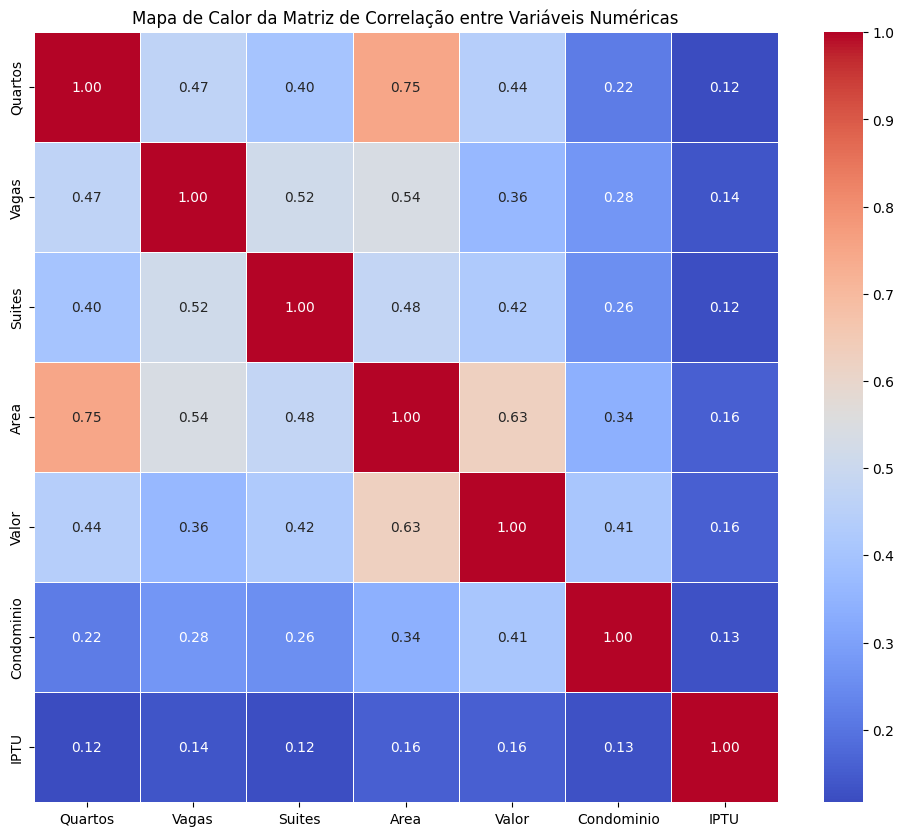

In [25]:
# Criar um mapa de calor para visualizar a matriz de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor da Matriz de Correlação entre Variáveis Numéricas')
plt.show()

O método do **Intervalo Interquartil (IQR)** para tratar os outliers em todas as variaveis_de_interesse. Isso removerá os valores estatisticamente extremos de cada coluna, proporcionando um DataFrame mais limpo e adequado para análises posteriores.

O tratamento de outliers para todas as variáveis de interesse (Quartos, Vagas, Suites, Area, Valor, Condominio e IPTU) foi concluído com sucesso. O DataFrame foi refinado de 21375 linhas para 15466 linhas após a remoção dos valores considerados estatisticamente atípicos.

<h3>Análise de Correlações Mais Relevantes</h3>
<p>Após a análise da matriz de correlação das variáveis numéricas originais, as seguintes relações importantes foram observadas:</p>
<table>
  <tr>
    <th>Variável 1</th>
    <th>Variável 2</th>
    <th>Correlação</th>
    <th>Interpretação Prática</th>
  </tr>
  <tr>
    <td>Area</td>
    <td>Quartos</td>
    <td>+0.75</td>
    <td>Forte correlação positiva. Imóveis com maior área geralmente possuem um número maior de quartos.</td>
  </tr>
  <tr>
    <td>Area</td>
    <td>Valor</td>
    <td>+0.63</td>
    <td>Correlação positiva moderada a forte. Imóveis com maior área tendem a ter um valor de aluguel mais elevado, o que é esperado no mercado imobiliário.</td>
  </tr>
  <tr>
    <td>Vagas</td>
    <td>Area</td>
    <td>+0.54</td>
    <td>Correlação positiva moderada. Propriedades com áreas maiores tendem a oferecer mais vagas de estacionamento.</td>
  </tr>
  <tr>
    <td>Vagas</td>
    <td>Suites</td>
    <td>+0.52</td>
    <td>Correlação positiva moderada. Imóveis com mais suítes (geralmente indicando maior padrão) tendem a ter mais vagas de estacionamento.</td>
  </tr>
  <tr>
    <td>Quartos</td>
    <td>Vagas</td>
    <td>+0.47</td>
    <td>Correlação positiva moderada. Mais quartos geralmente significam maior necessidade de vagas de estacionamento.</td>
  </tr>
  <tr>
    <td>Area</td>
    <td>Suites</td>
    <td>+0.48</td>
    <td>Correlação positiva moderada. Imóveis com maior área tendem a ter um número maior de suítes.</td>
  </tr>
  <tr>
    <td>Quartos</td>
    <td>Valor</td>
    <td>+0.44</td>
    <td>Correlação positiva moderada. O número de quartos tem uma influência considerável no valor do aluguel.</td>
  </tr>
  <tr>
    <td>Suites</td>
    <td>Valor</td>
    <td>+0.42</td>
    <td>Correlação positiva moderada. O número de suítes também contribui significativamente para o valor do aluguel.</td>
  </tr>
  <tr>
    <td>Condominio</td>
    <td>Valor</td>
    <td>+0.41</td>
    <td>Correlação positiva moderada. Imóveis com aluguel mais alto frequentemente vêm acompanhados de taxas de condomínio mais elevadas.</td>
  </tr>
  <tr>
    <td>Condominio</td>
    <td>IPTU</td>
    <td>+0.31</td>
    <td>Correlação positiva fraca a moderada. Há uma relação entre o valor do condomínio e o IPTU, pois ambos são custos associados ao imóvel e geralmente proporcionais ao seu valor ou tamanho.</td>
  </tr>
</table>

### 4.6 Codificação de Variáveis Categóricas

Agora que os dados numéricos estão limpos, precisamos transformar as variáveis categóricas ('Tipo' e 'Bairro') em um formato numérico que os modelos de *machine learning* possam entender. Utilizaremos a técnica de **One-Hot Encoding**.

O One-Hot Encoding cria novas colunas binárias para cada categoria única em uma variável. Por exemplo, se a coluna 'Tipo' tem as categorias 'Apartamento' e 'Casa', ela será substituída por duas novas colunas: 'Tipo_Apartamento' e 'Tipo_Casa'. Se um imóvel for um apartamento, 'Tipo_Apartamento' terá o valor 1 e 'Tipo_Casa' terá 0, e vice-versa. Isso evita que o modelo atribua uma ordem ou hierarquia artificial às categorias.

In [26]:
# Aplicando One-Hot Encoding para as colunas 'Tipo' e 'Bairro'
df_encoded = pd.get_dummies(df_aluguel, columns=['Tipo', 'Bairro'], drop_first=True, dtype=int)

print("Shape do DataFrame original:", df_aluguel.shape)
print("Shape do DataFrame após One-Hot Encoding:", df_encoded.shape)

# Exibindo as primeiras linhas do DataFrame codificado
display(df_encoded.head())

Shape do DataFrame original: (17128, 9)
Shape do DataFrame após One-Hot Encoding: (17128, 164)


,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Tipo_Casa,Tipo_Casa de Condomínio,Tipo_Casa de Vila,...,Bairro_Vidigal,Bairro_Vigário Geral,Bairro_Vila Isabel,Bairro_Vila Kosmos,Bairro_Vila Militar,Bairro_Vila Valqueire,Bairro_Vila da Penha,Bairro_Vista Alegre,Bairro_Zumbi,Bairro_Água Santa
0,1,0,0,40,1700.0,500.0,60.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,1,100,7000.0,980.0,250.0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,15,800.0,390.0,20.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,48,800.0,230.0,250.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,3,1,0,70,1200.0,980.0,250.0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


O DataFrame `df_encoded` agora contém as variáveis categóricas transformadas em colunas numéricas binárias. A opção `drop_first=True` foi usada para evitar a armadilha da variável dummy, removendo uma das categorias de cada variável original, o que é útil para evitar multicolinearidade em alguns modelos.

As variáveis categóricas 'Tipo' e 'Bairro' foram codificadas usando One-Hot Encoding. O DataFrame original com 9 colunas foi expandido para 164 colunas, o que significa que cada categoria única em 'Tipo' e 'Bairro' agora tem sua própria coluna binária. Isso prepara o seu conjunto de dados para modelos de machine learning que exigem entradas numéricas.

### 4.7 Engenharia de Features

Vamos criar algumas novas variáveis que podem ser úteis para a análise e modelagem: **Valor_por_Area** (valor por metro quadrado) e **Total_Comodos**. Estas novas *features* são derivadas das colunas existentes e visam fornecer mais informações úteis sobre os imóveis.

In [27]:
# Criando a feature 'Valor_por_Area'
# Para evitar divisão por zero, vamos tratar casos onde 'Area' pode ser 0, embora já tenhamos filtrado por 'Area' > 0.
df_aluguel['Valor_por_Area'] = df_aluguel['Valor'] / df_aluguel['Area']

# Criando a feature 'Total_Comodos'
df_aluguel['Total_Comodos'] = df_aluguel['Quartos'] + df_aluguel['Vagas'] + df_aluguel['Suites']

print("DataFrame após a criação das novas features:")
display(df_aluguel.head())

DataFrame após a criação das novas features:


,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_por_Area,Total_Comodos
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,42.500000,1
1,Casa,Jardim Botânico,2,0,1,100,7000.0,980.0,250.0,70.000000,3
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,53.333333,1
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,250.0,16.666667,1
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,980.0,250.0,17.142857,4


As novas *características* **`Valor_por_Area`** e **`Total_Comodos`** foram adicionadas ao DataFrame. **`Valor_por_Area`** representa o custo por metro quadrado, uma métrica importante no mercado imobiliário, enquanto **`Total_Comodos`** agrega o número de quartos, vagas e suítes, dando uma visão consolidada do tamanho e funcionalidade do imóvel.

### 4.8 Escalonamento de Variáveis Numéricas

Após a engenharia de *features*, é crucial realizar o **escalonamento das variáveis numéricas**. Muitas técnicas de *machine learning* (como Regressão Linear, SVMs e Redes Neurais) são sensíveis à escala das *features*. Variáveis com grandes intervalos de valores podem ter um peso desproporcionalmente maior na função de custo do modelo.

Utilizaremos o **`StandardScaler`** da biblioteca `scikit-learn`, que padroniza as *features* removendo a média e escalando para a variância unitária (desvio padrão 1). Isso faz com que a média de cada *feature* se torne 0 e o desvio padrão se torne 1, resultando em uma distribuição com média 0 e desvio padrão 1. Essa técnica é muito eficaz quando os dados seguem uma distribuição aproximadamente normal.

In [28]:
from sklearn.preprocessing import StandardScaler

# Definindo as variáveis numéricas para escalonamento
# Incluímos as features originais numéricas e as recém-criadas
numerical_cols = ['Quartos', 'Vagas', 'Suites', 'Area', 'Valor', 'Condominio', 'IPTU', 'Valor_por_Area', 'Total_Comodos']

# Instanciando o StandardScaler
scaler = StandardScaler()

# Aplicando o escalonamento nas colunas selecionadas do DataFrame df_aluguel
df_aluguel[numerical_cols] = scaler.fit_transform(df_aluguel[numerical_cols])

print("DataFrame após o escalonamento das variáveis numéricas:")
display(df_aluguel.head())
display(df_aluguel[numerical_cols].describe())

DataFrame após o escalonamento das variáveis numéricas:


,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_por_Area,Total_Comodos
0,Quitinete,Copacabana,-1.420300,-1.143466,-0.882611,-1.140879,-0.541519,-0.491087,-0.281287,0.666440,-1.464168
1,Casa,Jardim Botânico,-0.166982,-1.143466,0.778272,0.449087,2.992629,0.048047,-0.052886,2.344777,-0.292587
3,Apartamento,Centro,-1.420300,-1.143466,-0.882611,-1.803366,-1.141657,-0.614639,-0.329371,1.327603,-1.464168
4,Apartamento,Higienópolis,-1.420300,-1.143466,-0.882611,-0.928884,-1.141657,-0.794351,-0.052886,-0.910180,-1.464168
5,Apartamento,Vista Alegre,1.086335,0.226230,-0.882611,-0.345896,-0.874929,0.048047,-0.052886,-0.881118,0.293203


,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_por_Area,Total_Comodos
count,1.712800e+04,1.712800e+04,1.712800e+04,1.712800e+04,1.712800e+04,1.712800e+04,1.712800e+04,1.712800e+04,1.712800e+04
mean,1.074443e-16,-5.392956e-18,1.742340e-17,-4.148428e-17,-1.485137e-16,2.240151e-17,1.265271e-17,2.099105e-16,2.572025e-17
std,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00,1.000029e+00
min,-1.420300e+00,-1.143466e+00,-8.826106e-01,-1.935863e+00,-1.475067e+00,-1.051563e+00,-3.522109e-01,-1.622202e+00,-1.464168e+00
25%,-1.669822e-01,-1.143466e+00,-8.826106e-01,-6.638894e-01,-7.415649e-01,-4.573915e-01,-2.235854e-01,-7.067450e-01,-8.783776e-01
50%,-1.669822e-01,2.262301e-01,-8.826106e-01,-1.868994e-01,-2.747907e-01,-1.238018e-01,-5.288608e-02,-2.108727e-01,-2.925873e-01
75%,1.086335e+00,2.262301e-01,7.782721e-01,4.490873e-01,5.253937e-01,2.614550e-01,-5.288608e-02,4.631360e-01,8.789932e-01
max,2.339653e+00,5.705014e+00,2.439155e+00,3.364026e+00,3.043974e+00,5.566879e+01,7.902177e+01,2.686680e+01,4.393735e+00


As variáveis numéricas do DataFrame `df_aluguel` foram escalonadas usando o `StandardScaler`. Como você pode observar no `df.describe()`, as médias das colunas escalonadas são muito próximas de 0 e os desvios padrão são 1 (ou muito próximos de 1, devido à precisão numérica).

Este método primeiro calcula a média e o desvio padrão para cada coluna (ajusta) e depois transforma os dados para que cada coluna tenha uma média de 0 e um desvio padrão de 1. O código então imprime uma mensagem e exibe as primeiras linhas do DataFrame atualizado e as estatísticas descritivas para as colunas numéricas escalonadas, permitindo que você veja o efeito do escalonamento.

Com o escalonamento concluído, o seu DataFrame `df_aluguel` está agora com todas as variáveis numéricas padronizadas. Se você pretende usar o `df_encoded` (que possui as variáveis categóricas já codificadas), você pode replicar estas etapas de engenharia de *features* e escalonamento nesse DataFrame para ter um conjunto de dados final completamente preparado para modelagem.